In [1]:
#### Cellule 4.1.1 ####

 #Bibliothèque de lecture et d’écriture de fichiers CSV
   using CSV
#Bibliothèque de manipulation de données tabulaires
using DataFrames
# Bibliothèque de gestion des dates
using Dates
#Bibliothèque de calculs statistiques
using Statistics
#Bibliothèque d’algèbre linéaire
using LinearAlgebra
#Bibliothèque de génération aléatoire
  using Random
#Bibliothèque d’outils statistiques complémentaires
using StatsBase
#Bibliothèque de visualisation graphique
using Plots
#Bibliothèque de formatage d’affichage
using Printf
# Bibliothèque de sauvegarde et chargement de données au format JLD2
using JLD2

In [3]:
#### Cellule 4.1.2 #########

#Fixer la graine aléatoire pour assurer la reproductibilité
Random.seed!(123)

  #Dossier de sortie pour les résultats (figures, tables, etc.)
    OUTDIR = "outputs_chap4"
   isdir(OUTDIR) || mkpath(OUTDIR)

#Fichier contenant les données de prix historiques
     PRICE_FILE= "prices_tech.csv"

   #Liste des actifs étudiés
TICKERS= ["AAPL", "MSFT", "AMZN", "GOOG", "META"]

   #Nombre d'actifs
   N= length(TICKERS)

#Fréquence d’annualisation (données journalières)
  FREQ= 252

# Capital initial utilisé pour les trajectoires de richesse
  W0= 1.0

  # Paramètre pour la construction du contexte de volatilité
  #(fenêtre glissante pour estimer la volatilité)
Kvol = 20

#Paramètres de simulation Monte Carlo
  T_horizon= 252   # horizon de simulation ≈ 1 année boursière

   # nombre de scénarios simulés
   #(réduit pour limiter le coût computationnel)
   M_scen= 1000
    #M_scen= 5000

    #dans les expériences hors échantillon,
        # les régimes et paramètres seront recalculés
    # dynamiquement uniquement à partir du passé

#Affichage des paramètres principaux
println("Nombre d'actifs : ", N)
println("Horizon de simulation : ", T_horizon)
println("Nombre de scénarios : ", M_scen)

Nombre d'actifs : 5
Horizon de simulation : 252
Nombre de scénarios : 1000


In [9]:
#### Cellule 4.1.3 ####

#Vérification de l'existence du fichier de prix
 @assert isfile(PRICE_FILE) "Fichier introuvable : $PRICE_FILE"
  #Lecture du fichier CSV
 prices= CSV.read(PRICE_FILE, DataFrame)
#Vérification de la présence de la colonne Date
@assert "Date" in names(prices) "La colonne 'Date' est absente. Colonnes dispo : $(names(prices))"
# Conversion de la colonne Date si nécessaire
if !(eltype(prices.Date) <: Date)
    prices.Date = Date.(prices.Date)
end
#Conservation des colonnes utiles : Date + actifs étudiés
select!(prices, ["Date"; TICKERS]...)
# Tri chronologique
sort!(prices, :Date)
# Affichage d’un aperçu des données
println("Aperçu des données :")
println(first(prices, 3))
println(last(prices, 3))
println("Nombre de lignes : ", nrow(prices))

Aperçu des données :
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2015-01-02  24.2374  40.1536  15.426   26.2405    78.45
   2 │ 2015-01-05  23.5555  39.7826  15.1095  25.6935    77.19
   3 │ 2015-01-06  23.5575  39.1972  14.7645  25.098     76.15
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2025-12-29   273.76   487.1    232.07   314.39   658.69
   2 │ 2025-12-30   273.08   487.48   232.53   314.55   665.95
   3 │ 2025-12-31   271.86   483.62   230.82   313.8    660.09
Nombre de lignes : 2766


In [11]:
#### Cellule 4.1.4 ####

# #Contrôles de base sur les données de prix
for tk in TICKERS
      #Vérification de l'absence de valeurs manquantes
    miss= count(ismissing, prices[!, tk])
    @assert miss == 0 "Valeurs manquantes détectées dans $tk : $miss"
    #Vérification de la positivité des prix
    @assert minimum(prices[!, tk]) > 0 "Prix non positifs détectés dans $tk"
end
# Message de validation
println("Contrôles de base sur les prix : OK")

Contrôles de base sur les prix : OK


In [13]:
####### Cellule 4.1.5 ###

#Fonction de calcul des rendements simples :
# R_t = P_t / P_{t-1} - 1
simple_ret(p::AbstractVector{<:Real}) =
    p[2:end] ./ p[1:end-1] .- 1.0
 #Fonction de calcul des log-rendements :
#r_t =log(P_t / P_{t-1})
log_ret(p::AbstractVector{<:Real}) =
    log.(p[2:end] ./ p[1:end-1])

log_ret (generic function with 1 method)

In [15]:
#### Cellule 4.1.6 ##

#Nombre total d'observations de prix
  T= nrow(prices)

 #Initialisation des matrices de rendements :
    # R_simple : rendements simples (T-1 x N)
    # R_log : log-rendements (T-1 x N)
      R_simple = Matrix{Float64}(undef, T-1, N)
       R_log= Matrix{Float64}(undef, T-1, N)

#Calcul des rendements pour chaque actif

for (j, tk) in enumerate(TICKERS)
     #Extraction des prix et conversion en Float64
    p= Float64.(prices[!, tk])
    # Calcul des rendements simples
    R_simple[:, j] = simple_ret(p)
    # Calcul des log-rendements
    R_log[:, j] = log_ret(p)
end

# Ajustement des dates (perte d’une observation)
dates_ret = prices.Date[2:end]

# Affichage des dimensions
println("Dimensions R_simple : ", size(R_simple))
println("Dimensions R_log    : ", size(R_log))

Dimensions R_simple : (2765, 5)
Dimensions R_log    : (2765, 5)


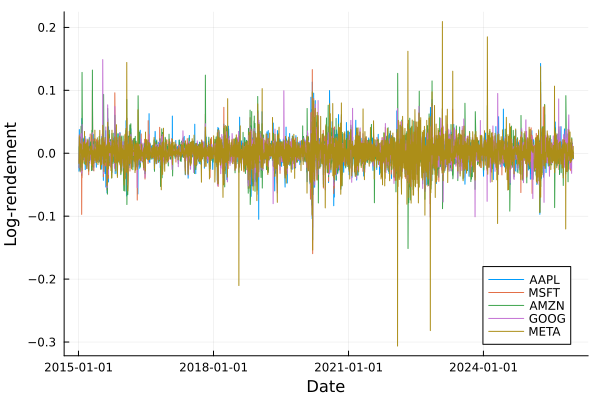

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 4\\outputs_chap4\\chap4_fig0_control_log_returns.png"

In [17]:
#### Cellule 4.1.7 ####

# Tracé des log-rendements pour le premier actif
p_ctrl = plot(
    dates_ret,
    R_log[:, 1],
    label = TICKERS[1],
     xlabel= "Date",
     ylabel= "Log-rendement",
    linewidth = 1
)

# Ajout des autres actifs sur le même graphique
for j in 2:N
    plot!(p_ctrl,
          dates_ret,
          R_log[:, j],
          label = TICKERS[j],
          linewidth = 1)
end

  #Affichage de la figure
  display(p_ctrl)

  #Sauvegarde de la figure
     savefig(p_ctrl, joinpath(OUTDIR, "chap4_fig0_control_log_returns.png"))

In [19]:
#### Cellule 4.1.8 #######

#Construction d’un proxy de marché :
#moyenne équipondérée des log-rendements des actifs
   R_mkt= vec(mean(R_log, dims=2))

# Affichage de la dimension du vecteur obtenu
println("Dimensions du proxy de marché : ", size(R_mkt))

Dimensions du proxy de marché : (2765,)


In [21]:
####Cellule 4.1.9 #######

  #Initialisation du vecteur de volatilité
   vol= fill(NaN, length(R_mkt))

  #Calcul de la volatilité réalisée (écart-type glissant)
   #sur une fenêtre de taille Kvol
for t in Kvol:length(R_mkt)
    vol[t] = std(R_mkt[t-Kvol+1:t])
end

#Identification des indices valides (où la volatilité est définie)
valid = .!isnan.(vol)

#Construction des données conditionnelles (contexte)
   R_log_ctx = R_log[valid, :]
   R_simple_ctx = R_simple[valid, :]
    vol_ctx= vol[valid]
    dates_ctx = dates_ret[valid]
   R_mkt_ctx= R_mkt[valid]

            #IMPORTANT :
        #les seuils de régimes ne sont pas encore calculés ici.
        #dans le backtest hors échantillon,
        #ils seront recalculés dynamiquement uniquement
        #à partir des données passées disponibles.

#Affichage des dimensions
println("Dimensions après construction du contexte : ", size(R_log_ctx))
println("Nombre de dates retenues : ", length(dates_ctx))

Dimensions après construction du contexte : (2746, 5)
Nombre de dates retenues : 2746


In [25]:
#### Cellule 4.1.10 #####

#Fonction de classification en régimes de volatilité :
   #1 = faible volatilité
   #2 = volatilité moyenne
   #3 = forte volatilité
function regime(v, q1, q2)
    if v <= q1
        return 1
    elseif v <= q2
        return 2
    else
        return 3
    end
end

#Fonction auxiliaire :
#calcule les seuils de régimes uniquement à partir d'un historique passé
function past_volatility_thresholds(vol_past::Vector{Float64})
    q1 = quantile(vol_past, 1/3)
    q2= quantile(vol_past, 2/3)
    return q1, q2
end

  #Seuils descriptifs globaux
   #ils servent seulement à résumer la structure globale des régimes
    #et ne seront pas utilisés dans le backtest hors échantillon
    q1_desc = quantile(vol_ctx, 1/3)
     q2_desc= quantile(vol_ctx, 2/3)

#Régimes descriptifs associés aux seuils globaux
regimes_desc = [regime(v, q1_desc, q2_desc) for v in vol_ctx]

#Affichage des seuils descriptifs et de la répartition
println("Seuil descriptif q1_desc = ", q1_desc)
println("Seuil descriptif q2_desc = ", q2_desc)
println("Répartition descriptive des régimes : ", countmap(regimes_desc))

println("Les seuils q1_t et q2_t seront recalculés dynamiquement à partir du passé dans le backtest.")

Seuil descriptif q1_desc = 0.010517483639269062
Seuil descriptif q2_desc = 0.015506578581164185
Répartition descriptive des régimes : Dict(2 => 915, 3 => 915, 1 => 916)
Les seuils q1_t et q2_t seront recalculés dynamiquement à partir du passé dans le backtest.


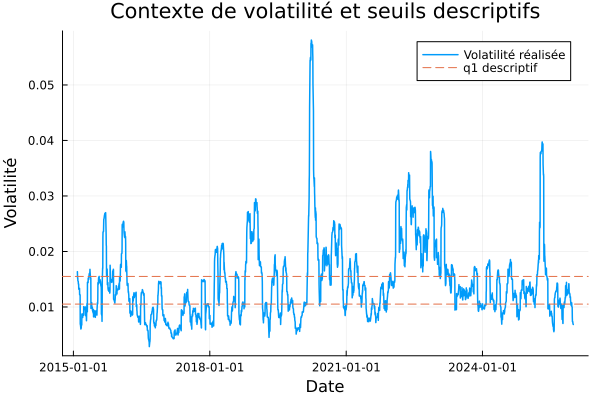

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 4\\outputs_chap4\\chap4_fig1_contexte.png"

In [27]:
#### Cellule 4.1.11 #######

 #Tracé de la volatilité réalisée dans le temps
p1 = plot(
    dates_ctx,
    vol_ctx,
    lw = 1.5,
    label= "Volatilité réalisée"
)

   #Ajout des seuils descriptifs de régimes
  #ces seuils ne sont pas utilisés directement dans le backtest
    hline!([q1_desc, q2_desc],
       linestyle = :dash,
       label= ["q1 descriptif" "q2 descriptif"])

   #Habillage du graphique
    xlabel!("Date")
    ylabel!("Volatilité")
    title!("Contexte de volatilité et seuils descriptifs")

#Affichage
display(p1)

#Sauvegarde
savefig(p1, joinpath(OUTDIR, "chap4_fig1_contexte.png"))

In [29]:
#### Cellule 4.1.12 ####

#Estimation descriptive globale (toutes observations confondues)
   μ_global_log = vec(mean(R_log_ctx, dims=1))
    Σ_global_log= cov(R_log_ctx, corrected=true)

#Dictionnaires pour stocker les estimations descriptives par régime
  μ_reg_log = Dict{Int, Vector{Float64}}()
   Σ_reg_log = Dict{Int, Matrix{Float64}}()
    R_regime= Dict{Int, Matrix{Float64}}()

#Estimation descriptive conditionnelle par régime de volatilité
for k in 1:3

     #Indices correspondant au régime descriptif k
    idx= findall(regimes_desc .== k)

    #Sous-échantillon des rendements dans le régime k
    Rk= R_log_ctx[idx, :]
     #Stockage des données du régime
    R_regime[k] = Rk

     #Estimation du vecteur moyen conditionnel
    μ_reg_log[k] = vec(mean(Rk, dims=1))

    #Estimation de la matrice de covariance conditionnelle
    Σ_reg_log[k]= cov(Rk, corrected=true)

end

#Affichage des résultats descriptifs
println("Estimations descriptives globales et conditionnelles terminées.")
    println("ATTENTION : ces estimations descriptives")
        println("ne seront pas utilisées directement")
     println("dans le backtest hors échantillon.")

println("\nNombre d'observations par régime descriptif :")
for k in 1:3
    println("Régime ", k, " : ", size(R_regime[k], 1), " observations")
end

Estimations descriptives globales et conditionnelles terminées.
ATTENTION : ces estimations descriptives
ne seront pas utilisées directement
dans le backtest hors échantillon.

Nombre d'observations par régime descriptif :
Régime 1 : 916 observations
Régime 2 : 915 observations
Régime 3 : 915 observations


In [31]:
#### Cellule 4.1.13 ####

#Création d’un tableau contenant les actifs
df_mu = DataFrame(Asset = TICKERS)

#Ajout des rendements moyens descriptifs estimés pour chaque régime
#ces valeurs résument les régimes sur l'échantillon complet
#elles ne sont pas utilisées directement dans le backtest hors échantillon
for k in 1:3
    df_mu[!, Symbol("mu_desc_regime_" * string(k))] = μ_reg_log[k]
end
  #Affichage du tableau
 display(df_mu)

  #Export du tableau au format CSV pour utilisation descriptive dans le rapport
     CSV.write(joinpath(OUTDIR, "chap4_table_mu_regimes_desc.csv"), df_mu)

Row,Asset,mu_desc_regime_1,mu_desc_regime_2,mu_desc_regime_3
,String,Float64,Float64,Float64
1,AAPL,0.00135821,0.000242355,0.000964163
2,MSFT,0.00132458,0.000437542,0.0011159
3,AMZN,0.00131028,0.000749004,0.000744284
4,GOOG,0.00104323,0.0010822,0.000565364
5,META,0.000973956,0.000255815,0.00113291


"outputs_chap4\\chap4_table_mu_regimes_desc.csv"

In [35]:
#### Cellule 4.1.14 ######

#Création d’un tableau contenant les actifs
df_var= DataFrame(Asset = TICKERS)

    #Ajout des variances descriptives
    #(diagonale des matrices de covariance conditionnelles)
    #calculées sur l'échantillon complet
        for k in 1:3
            df_var[!, Symbol("var_desc_regime_" * string(k))] = diag(Σ_reg_log[k])
        end

#Affichage du tableau
display(df_var)

  #Export du tableau au format CSV
  #pour une utilisation descriptive dans le rapport
    CSV.write(joinpath(OUTDIR, "chap4_table_var_regimes_desc.csv"), df_var)

Row,Asset,var_desc_regime_1,var_desc_regime_2,var_desc_regime_3
,String,Float64,Float64,Float64
1,AAPL,0.000151061,0.000230303,0.000602186
2,MSFT,9.35607e-5,0.000219307,0.00053495
3,AMZN,0.00015104,0.000338649,0.000777061
4,GOOG,0.00013027,0.000305795,0.000549229
5,META,0.000182739,0.000354119,0.00117562


"outputs_chap4\\chap4_table_var_regimes_desc.csv"

In [39]:
##Cellule 4.1.15 ####

  #Initialisation de la matrice de transition descriptive
  #(3 régimes de volatilité)
     P_desc= zeros(3, 3)

#Comptage descriptif des transitions observées entre régimes
for t in 1:length(regimes_desc)-1

    i= regimes_desc[t]      #régime à la date t
    j = regimes_desc[t+1]    #régime à la date t+1

    #Incrément du compteur de transition i → j
    P_desc[i, j] += 1.0
end

#Normalisation ligne par ligne pour obtenir des probabilités
for i in 1:3

    row_sum= sum(P_desc[i, :])
    #Vérification qu’il y a au moins une transition observée
    @assert row_sum > 0 "Ligne $i de la matrice de transition vide"

     #Conversion en probabilités conditionnelles
    P_desc[i, :] ./= row_sum

end

    #Affichage de la matrice de transition descriptive
    println("Matrice de transition descriptive estimée :")
        display(P_desc)



Matrice de transition descriptive estimée :


3×3 Matrix{Float64}:
 0.942077   0.0568306  0.0010929
 0.0579235  0.907104   0.0349727
 0.0010929  0.0360656  0.962842

In [41]:
#### Cellule 4.1.16 ####

    #Fonction de décomposition de Cholesky avec régularisation :
    #elle permet d'obtenir une matrice triangulaire L telle que
    #Σ ≈ L * L', même lorsque Σ est presque singulière
function cholesky_psd(Σ::Matrix{Float64}; eps0::Float64=1e-10, max_iter::Int=8)
    #Taille de la matrice
       N= size(Σ, 1)

    #Symétrisation pour limiter les erreurs numériques
        Σsym= 0.5* (Σ + Σ')

      #Niveau initial de régularisation
        eps= eps0

    #Tentatives successives de décomposition
    for _ in 1:max_iter
        try
            return cholesky(Σsym + eps * I(N)).L
        catch
            eps *= 10
        end
    end

    #Message d'erreur si la décomposition échoue malgré la régularisation
    error("Échec de la décomposition de Cholesky, même après régularisation.")
end

#Dictionnaire contenant les matrices de Cholesky descriptives par régime
L_reg_desc = Dict{Int, Matrix{Float64}}()

#Calcul de la décomposition pour chaque régime descriptif
for k in 1:3
    L_reg_desc[k] = cholesky_psd(Σ_reg_log[k])
end

#Message de confirmation
println("Décompositions de Cholesky descriptives calculées pour les 3 régimes.")
println("Dans le backtest hors échantillon, elles devront être recalculées à partir du passé.")

Décompositions de Cholesky descriptives calculées pour les 3 régimes.
Dans le backtest hors échantillon, elles devront être recalculées à partir du passé.


In [43]:
#### Cellule 4.1.17 ####

  #Fonction de simulation d’une trajectoire de régimes
  #à partir de la matrice de transition P
function simulate_regime_path(P::Matrix{Float64}, T_horizon::Int; r0::Int=2)

    #Vecteur contenant les régimes simulés
      c= Vector{Int}(undef, T_horizon)
     #Régime initial
    c[1] = r0
    #Simulation récursive selon les probabilités de transition
    for t in 2:T_horizon
        c[t] = sample(1:3, Weights(P[c[t-1], :]))
    end

    return c
end
  #Fonction de simulation d’une trajectoire de log-rendements
   #conditionnellement à la trajectoire de régimes simulée
function simulate_logreturn_path(μ_reg_log, L_reg, c_path::Vector{Int})

    #Horizon de simulation
     T_horizon = length(c_path)
    # Nombre d'actifs
     N= length(μ_reg_log[1])
    #Matrice des log-rendements simulés
    Rlog = Matrix{Float64}(undef, T_horizon, N)
    #Simulation date par date
    for t in 1:T_horizon
        k= c_path[t]   # régime courant
        z = randn(N)  # choc gaussien standard
        Rlog[t, :] = μ_reg_log[k] + L_reg[k] * z
    end

    return Rlog
end

# Conversion des log-rendements en rendements simples
function log_to_simple(Rlog::Matrix{Float64})
    return exp.(Rlog) .- 1.0
end
# Reconstruction d’une trajectoire de prix à partir des log-rendements
function price_path_from_logreturns(r::Vector{Float64}; S0::Float64=1.0)

    #Vecteur des prix simulés
    S= Vector{Float64}(undef, length(r)+1)
     #Prix initial
     S[1]= S0
     #Mise à jour récursive des prix
    for t in 1:length(r)
        S[t+1] = S[t] * exp(r[t])
    end

    return S
end

# Message de confirmation
println("Fonctions de simulation définies.")

Fonctions de simulation définies.


In [45]:
#### Cellule 4.1.18 ####

#Initialisation des structures de stockage des scénarios

  #Trajectoires de régimes simulées
    scenario_regimes = Vector{Vector{Int}}(undef, M_scen)

  #Log-rendements simulés (T_horizon x N)
    scenario_Rlog = Vector{Matrix{Float64}}(undef, M_scen)

  #Rendements simples simulés
    scenario_Rsimple = Vector{Matrix{Float64}}(undef, M_scen)

  #Régime initial (choix neutre)
     r0 = 2

            #IMPORTANT :
                #les scénarios générés dans cette cellule sont descriptifs.
                # ils utilisent les paramètres estimés sur l'échantillon complet :
                # P_desc, μ_reg_log et L_reg_desc.
            #
            #dans le backtest hors échantillon,
            #ces paramètres devront être recalculés dynamiquement
            #uniquement à partir des données passées.

#Génération des scénarios Monte Carlo descriptifs
for m in 1:M_scen

    #Simulation d’une trajectoire de régimes
    c_path = simulate_regime_path(P_desc, T_horizon; r0=r0)

     #Simulation des log-rendements conditionnels aux régimes
    Rlog_m = simulate_logreturn_path(μ_reg_log, L_reg_desc, c_path)

     #Conversion en rendements simples
    Rsimple_m = log_to_simple(Rlog_m)
      #Stockage
    scenario_regimes[m] = c_path
    scenario_Rlog[m] = Rlog_m
    scenario_Rsimple[m]= Rsimple_m

end

#Vérifications
println("Nombre de scénarios générés : ", M_scen)
println("Dimension d'un scénario log-rendements : ", size(scenario_Rlog[1]))
println("Dimension d'un scénario rendements simples : ", size(scenario_Rsimple[1]))

Nombre de scénarios générés : 1000
Dimension d'un scénario log-rendements : (252, 5)
Dimension d'un scénario rendements simples : (252, 5)


In [47]:
#### Cellule 4.1.19 ####

  #Empilement de tous les scénarios descriptifs de log-rendements
   #On obtient une grande matrice (M_scen * T_horizon) x N
      all_sim_logreturns = vcat(scenario_Rlog...)

#Calcul des statistiques empiriques simulées

  #Moyenne simulée descriptive (par actif)
    mean_sim = vec(mean(all_sim_logreturns, dims=1))

  #Variance simulée descriptive (par actif)
    var_sim= vec(var(all_sim_logreturns, dims=1))

  #Construction d’un tableau de synthèse
    sim_stats = DataFrame(
        Asset= TICKERS,
        Mean_sim_desc = mean_sim,
        Var_sim_desc = var_sim
    )

#Affichage
println("Statistiques empiriques descriptives des scénarios simulés :")
display(sim_stats)

#Export pour utilisation descriptive dans le rapport
CSV.write(joinpath(OUTDIR, "chap4_table_sim_stats_desc.csv"), sim_stats)

Statistiques empiriques descriptives des scénarios simulés :


Row,Asset,Mean_sim_desc,Var_sim_desc
,String,Float64,Float64
1,AAPL,0.000867646,0.000316545
2,MSFT,0.000910212,0.000273016
3,AMZN,0.000894556,0.000407691
4,GOOG,0.000891055,0.000320813
5,META,0.000797527,0.000547111


"outputs_chap4\\chap4_table_sim_stats_desc.csv"

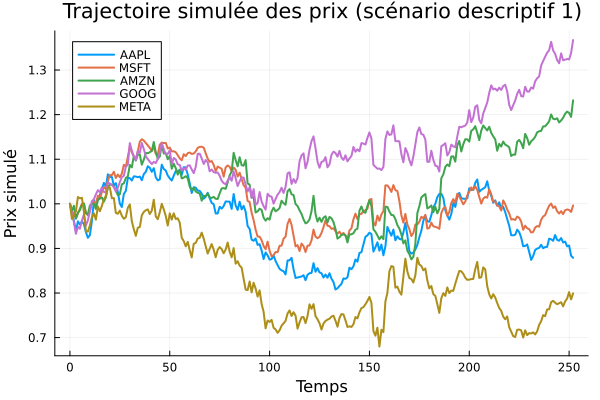

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 4\\outputs_chap4\\chap4_fig2_scenarios_prix.png"

In [49]:
#### Cellule 4.1.20 ####

#Choix du scénario à visualiser (ici le premier)
   m= 1

#Initialisation du graphique
p_scen = plot(
    title = "Trajectoire simulée des prix (scénario descriptif 1)",
    xlabel = "Temps",
    ylabel = "Prix simulé",
    legend = :topleft
)

#Tracé des trajectoires de prix pour chaque actif
for j in 1:N

     #Reconstruction de la trajectoire de prix
     #à partir des log-rendements simulés
      path_j = price_path_from_logreturns(scenario_Rlog[m][:, j]; S0=1.0)

     #Ajout au graphique
    plot!(p_scen, 0:T_horizon, path_j, lw=2, label=TICKERS[j])

end

#Affichage
display(p_scen)

#Sauvegarde de la figure
savefig(p_scen, joinpath(OUTDIR, "chap4_fig2_scenarios_prix.png"))

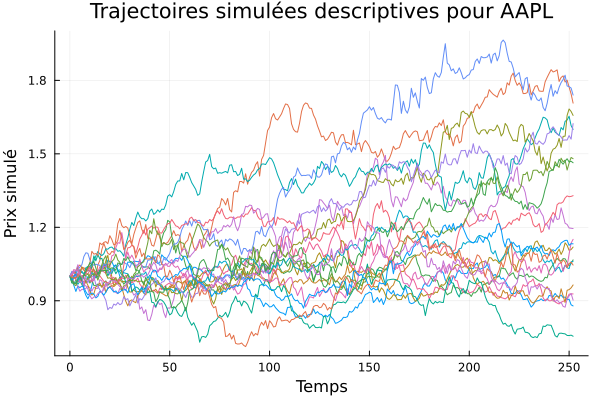

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 4\\outputs_chap4\\chap4_fig3_multi_scenarios_asset1.png"

In [51]:
#### Cellule 4.1.21 ####

#Choix de l’actif à analyser (ici AAPL)
asset_id = 1

#Initialisation du graphique
p_multi = plot(
    title = "Trajectoires simulées descriptives pour $(TICKERS[asset_id])",
    xlabel = "Temps",
    ylabel= "Prix simulé",
    legend = false
)

   #Tracé de plusieurs scénarios simulés (ici 20)
for m in 1:20

    #Reconstruction de la trajectoire de prix pour le scénario m
    path_m = price_path_from_logreturns(
        scenario_Rlog[m][:, asset_id];
        S0 = 1.0
    )
     # Ajout au graphique
    plot!(p_multi, 0:T_horizon, path_m, lw=1)

end
 #Affichage
display(p_multi)
#Sauvegarde
savefig(p_multi, joinpath(OUTDIR, "chap4_fig3_multi_scenarios_asset1.png"))

In [53]:
#### Cellule 4.1.22 ####

#Sauvegarde des objets essentiels du chapitre 4
#afin de permettre une réutilisation ultérieure sans recalcul

@save joinpath(OUTDIR, "chap4_scenarios_data.jld2")  μ_reg_log Σ_reg_log L_reg_desc P_desc scenario_regimes scenario_Rlog scenario_Rsimple q1_desc q2_desc regimes_desc vol_ctx dates_ctx TICKERS

println("Objets sauvegardés dans : ",
        joinpath(OUTDIR, "chap4_scenarios_data.jld2"))

Objets sauvegardés dans : outputs_chap4\chap4_scenarios_data.jld2
